In [5]:
#IMPORTACION DE LIBERIAS

# Manejo de datos
import numpy as np
import pandas as pd

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

In [6]:
load_dotenv()

USER = os.getenv('POSTGRES_USER')
PASSWORD = os.getenv('POSTGRES_PASSWORD')
HOST = os.getenv('POSTGRES_HOST')
PORT = os.getenv('POSTGRES_PORT') 
DB = os.getenv('POSTGRES_DB')

engine = create_engine(f'postgresql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}')

print("Conexión a la base de datos establecida")

Conexión a la base de datos establecida


In [7]:
query = """
SELECT 
    o.order_id,
    o.order_purchase_timestamp,
    i.price,
    i.freight_value,
    p.product_category_name,
    i.order_item_id
FROM olist_orders_dataset o
INNER JOIN olist_order_items_dataset i 
    ON o.order_id = i.order_id
INNER JOIN olist_products_dataset p 
    ON i.product_id = p.product_id
WHERE o.order_status = 'delivered'
  AND p.product_category_name IS NOT NULL;
"""


In [9]:
# Extraemos el dataset maestro utilizando el motor de conexión que ya tenías (engine)
df_master = pd.read_sql(query, engine)

# Convertimos inmediatamente la fecha de texto a formato Datetime de Pandas
df_master['order_purchase_timestamp'] = pd.to_datetime(df_master['order_purchase_timestamp'])

print("Dataset maestro primera version")
print(df_master.info())
print()
print(df_master.head())


Dataset maestro primera version
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108660 entries, 0 to 108659
Data columns (total 6 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  108660 non-null  object        
 1   order_purchase_timestamp  108660 non-null  datetime64[ns]
 2   price                     108660 non-null  float64       
 3   freight_value             108660 non-null  float64       
 4   product_category_name     108660 non-null  object        
 5   order_item_id             108660 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 5.0+ MB
None

                           order_id order_purchase_timestamp  price  \
0  00018f77f2f0320c557190d7a144bdd3      2017-04-26 10:53:06  239.9   
1  000229ec398224ef6ca0657da4fc703e      2018-01-14 14:33:31  199.0   
2  00042b26cf59d7ce69dfabb4e55b4fd9      2017-02-04 13

In [10]:
# 1. Preparación temporal (Agrupar por Año y Mes) de '2017-10-02 10:56:33' a '2017-10'
df_master['year_month'] = df_master['order_purchase_timestamp'].dt.to_period('M')

# Agrupamos contando cuántos artículos se vendieron en cada mes
ventas_mensuales = df_master.groupby('year_month').size().reset_index(name='total_articulos_vendidos')

# Convertimos el periodo a texto para que Seaborn lo grafique sin problemas
ventas_mensuales['year_month'] = ventas_mensuales['year_month'].astype(str)


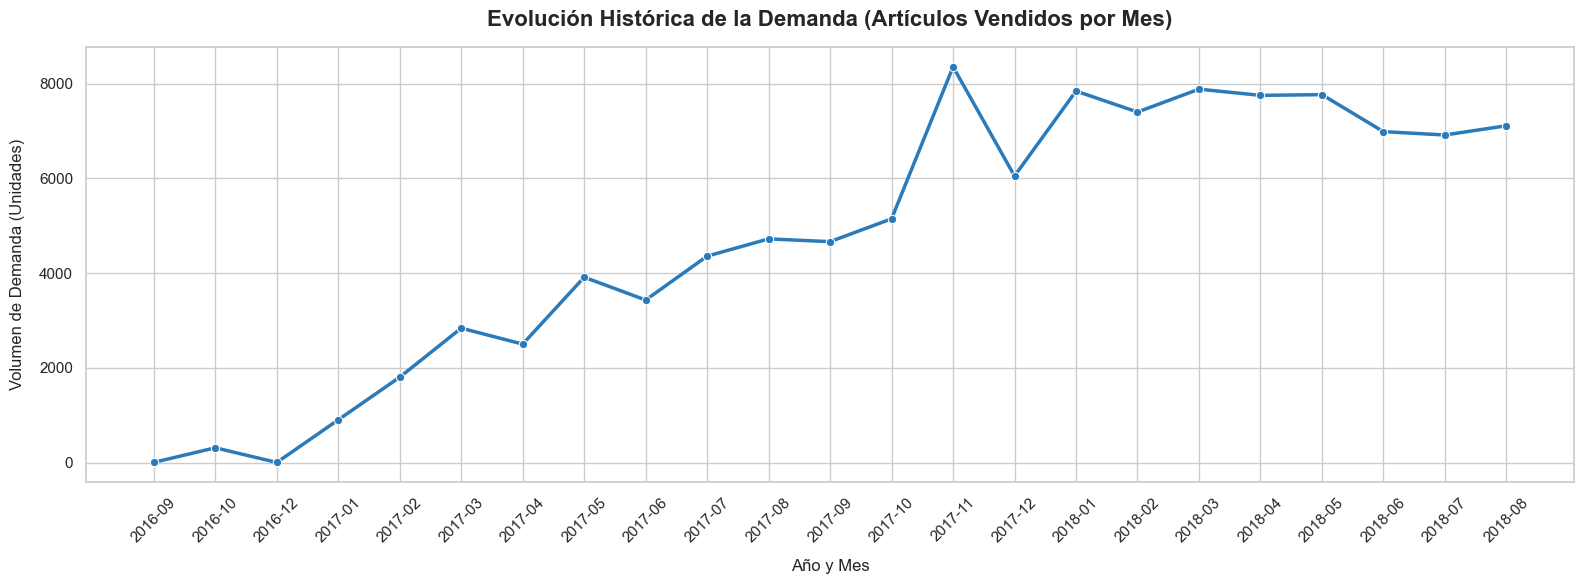

In [11]:
# Realizar graficos cruzados, cómo se comporta la variable del tiempo.
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

sns.lineplot(
    data=ventas_mensuales, 
    x='year_month', 
    y='total_articulos_vendidos', 
    marker='o',                  # Pone un punto en cada mes
    color='#2b7bba',             # Azul corporativo
    linewidth=2.5
)

# 4. Títulos y etiquetas (Formato presentación ejecutiva)
plt.title('Evolución Histórica de la Demanda (Artículos Vendidos por Mes)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Año y Mes', fontsize=12, labelpad=10)
plt.ylabel('Volumen de Demanda (Unidades)', fontsize=12, labelpad=10)

# Inclinamos las etiquetas del eje X para que no se encimen
plt.xticks(rotation=45) 

# Ajustamos los márgenes y mostramos
plt.tight_layout()
plt.show()

In [ ]:
# Preparación Mínima (El "Mini" Feature Engineering)

In [ ]:
# Entrenar el Baseline